In [244]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from matplotlib.patches import Ellipse
from astropy.visualization import ZScaleInterval

In [245]:
isDistributionplotting = False

selected_group = "edgeLarge"

EDGE_PERCENTILE = 0.995

In [246]:
fits_path = "../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits"
catalogue_path = "../data/raw/catalogue/jwst_bubble_properties_A.txt"
output_file = "../outputs/figures/distributions"

os.makedirs(output_file, exist_ok=True)

hdu = fits.open(fits_path)
image = hdu[1].data
wcs = WCS(hdu[1].header)

df = pd.read_csv(catalogue_path)

print(image.shape)
print(df.head())

(1177, 2380)
   ID       RA_DMS      DEC_DMS  SEMI_MAJ_PC  SEMI_MIN_PC  AVG_RAD_PC  PA_DEG  \
0   1  24d08m55.9s   15d48m7.9s           86           86          86       0   
1   2  24d08m56.7s   15d48m2.9s           24           24          24       0   
2   3  24d08m57.0s   15d48m9.0s           42           42          42       0   
3   4  24d08m58.0s  15d47m44.9s           25           25          25       0   
4   5  24d08m58.2s   15d48m2.6s           24           24          24       0   

   ARM  DIST_ARM_PC  GAL_RAD_KPC  
0    3          145         5.22  
1    3          127         5.05  
2    3          138         5.21  
3    3          101         4.54  
4    3          114         4.98  


Set DATE-AVG to '2022-07-17T12:01:53.586' from MJD-AVG.
Set DATE-END to '2022-07-17T12:54:46.016' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -37.754891 from OBSGEO-[XYZ].
Set OBSGEO-H to 1738895745.202 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [247]:
# Dividing bubbles into n balanced size groups

df["SIZE_CLASS"] = pd.qcut(
    df["AVG_RAD_PC"],
    q=5,
    labels=["tiny", "small", "medium", "large", "giants"]
)

# Separating else large bubbles

edge_threshold = df["AVG_RAD_PC"].quantile(EDGE_PERCENTILE)

print("edgeLarge threshold:", edge_threshold)

df["SIZE_CLASS"] = df["SIZE_CLASS"].astype(str)

df.loc[
    df["AVG_RAD_PC"] >= edge_threshold,
    "SIZE_CLASS"
] = "edgeLarge"


# Show counts
print(df["SIZE_CLASS"].value_counts())

# Show actual radius ranges
for group in ["tiny", "small", "medium", "large", "giants", "edgeLarge"]:

    subset = df[df["SIZE_CLASS"] == group]

    print(f"\n{group}")
    print("Count:", len(subset))
    print("Min AVG_RAD_PC:", subset["AVG_RAD_PC"].min())
    print("Max AVG_RAD_PC:", subset["AVG_RAD_PC"].max())

edgeLarge threshold: 228.07000000000016
SIZE_CLASS
tiny         379
small        359
large        329
giants       322
medium       296
edgeLarge      9
Name: count, dtype: int64

tiny
Count: 379
Min AVG_RAD_PC: 6
Max AVG_RAD_PC: 18

small
Count: 359
Min AVG_RAD_PC: 19
Max AVG_RAD_PC: 24

medium
Count: 296
Min AVG_RAD_PC: 25
Max AVG_RAD_PC: 30

large
Count: 329
Min AVG_RAD_PC: 31
Max AVG_RAD_PC: 41

giants
Count: 322
Min AVG_RAD_PC: 42
Max AVG_RAD_PC: 227

edgeLarge
Count: 9
Min AVG_RAD_PC: 229
Max AVG_RAD_PC: 552


In [248]:
# Conversion constants

distance_pc = 9.77e6

cdelt1 = abs(hdu[1].header["CDELT1"])
cdelt2 = abs(hdu[1].header["CDELT2"])

pixel_scale_arcsec = ((cdelt1 + cdelt2) / 2) * 3600
pc_per_arcsec = distance_pc / 206265
pc_per_pixel = pixel_scale_arcsec * pc_per_arcsec

print("pc_per_pixel:", pc_per_pixel)

pc_per_pixel: 5.254140159227344


In [249]:
df_filtered = df[df["SIZE_CLASS"] == selected_group]

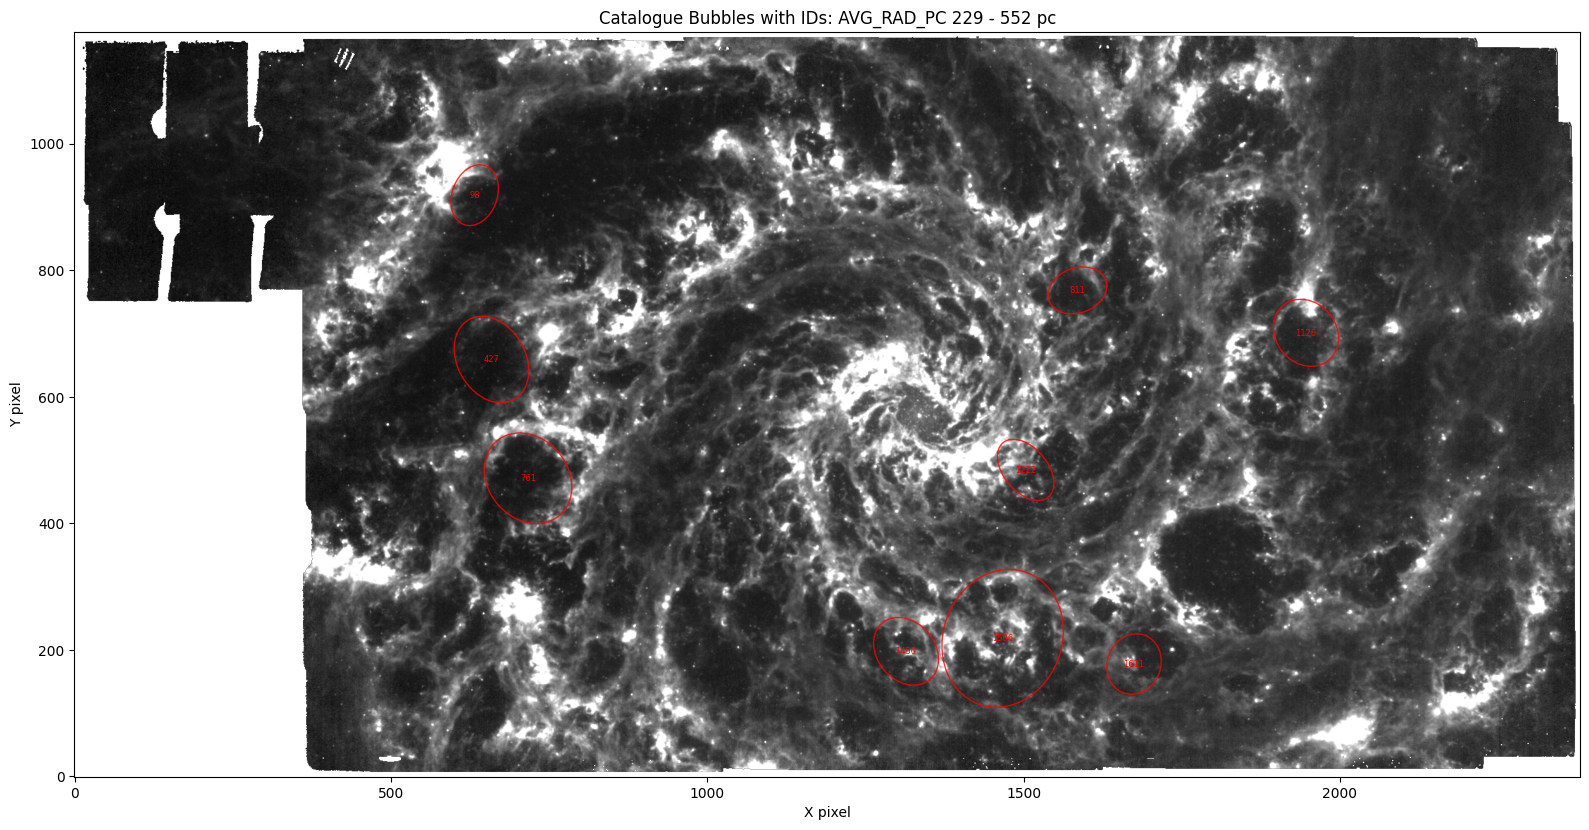

In [250]:
# Plotting all bubbles with ID labels

interval = ZScaleInterval()
vmin, vmax = interval.get_limits(image)

fig, ax = plt.subplots(figsize=(16, 10))

ax.imshow(image, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)

for _, row in df_filtered.iterrows():

    AVG_RAD_PC_MIN = df_filtered["AVG_RAD_PC"].min()
    AVG_RAD_PC_MAX = df_filtered["AVG_RAD_PC"].max()
    
    bubble_id = int(row["ID"])

    coord = SkyCoord(
        row["RA_DMS"],
        row["DEC_DMS"],
        unit=(u.hourangle, u.deg),
        frame="icrs"
    )

    x, y = wcs.world_to_pixel(coord)

    semi_major_pix = row["SEMI_MAJ_PC"] / pc_per_pixel
    semi_minor_pix = row["SEMI_MIN_PC"] / pc_per_pixel

    width = 2 * semi_major_pix
    height = 2 * semi_minor_pix

    pa = row["PA_DEG"]

    ellipse = Ellipse(
        (x, y),
        width=width,
        height=height,
        angle=pa,
        edgecolor="red",
        facecolor="none",
        linewidth=1.0,
        alpha=0.8
    )

    ax.add_patch(ellipse)

    ax.text(
        x,
        y,
        str(bubble_id),
        color="red",
        fontsize=6,
        ha="center",
        va="center"
    )

ax.set_title("Original Catalogue Bubbles: Red Ellipses with Bubble IDs")
ax.set_title(f"Catalogue Bubbles with IDs: AVG_RAD_PC {AVG_RAD_PC_MIN} - {AVG_RAD_PC_MAX} pc")
ax.set_xlabel("X pixel")
ax.set_ylabel("Y pixel")

plt.tight_layout()
plt.show()

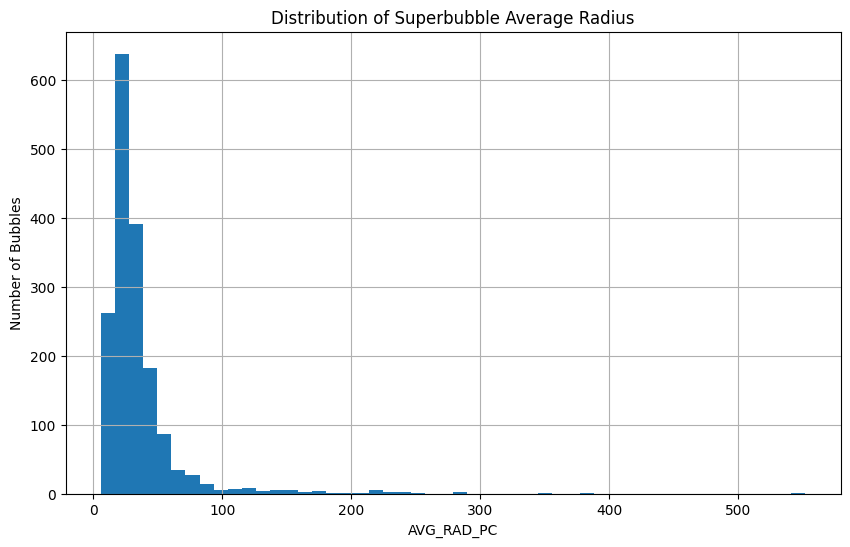

Saved: ../outputs/figures/distributions/avg_radius_distribution_linear_A.png


In [259]:
plt.figure(figsize=(10, 6))

plt.hist(df["AVG_RAD_PC"], bins=50)

plt.xlabel("AVG_RAD_PC")
plt.ylabel("Number of Bubbles")
plt.title("Distribution of Superbubble Average Radius")

plt.grid(True)

if isDistributionplotting = True:
    
    linear_path = os.path.join(
        output_file,
        "avg_radius_distribution_linear_A.png"
    )
    
    plt.savefig(linear_path, dpi=300, bbox_inches="tight")
    
    plt.show()
    
    print("Saved:", linear_path)

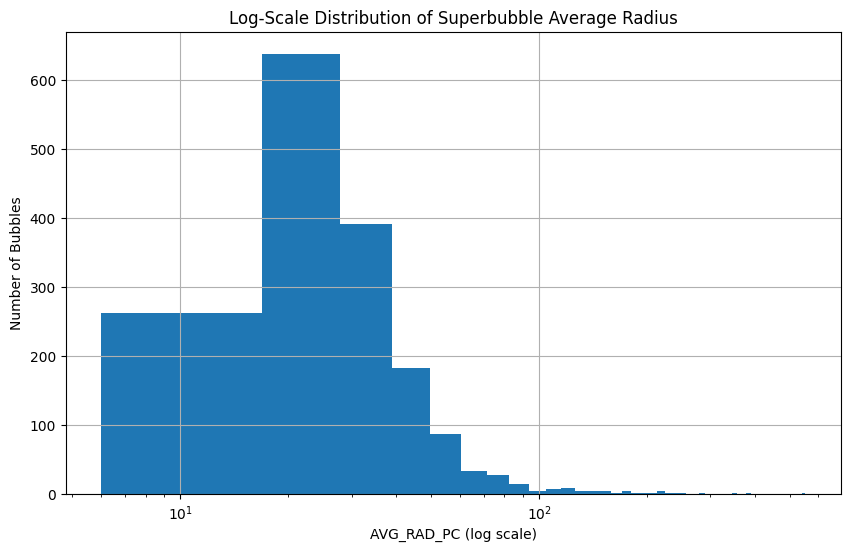

Saved: ../outputs/figures/distributions/avg_radius_distribution_log_A.png


In [261]:
plt.figure(figsize=(10, 6))

plt.hist(df["AVG_RAD_PC"], bins=50)

plt.xscale("log")

plt.xlabel("AVG_RAD_PC (log scale)")
plt.ylabel("Number of Bubbles")

plt.title("Log-Scale Distribution of Superbubble Average Radius")

plt.grid(True)

if isDistributionplotting = True:
    
    log_path = os.path.join(
        output_file,
        "avg_radius_distribution_log_A.png"
    )
    
    plt.savefig(log_path, dpi=300, bbox_inches="tight")
    
    plt.show()
    
    print("Saved:", log_path)

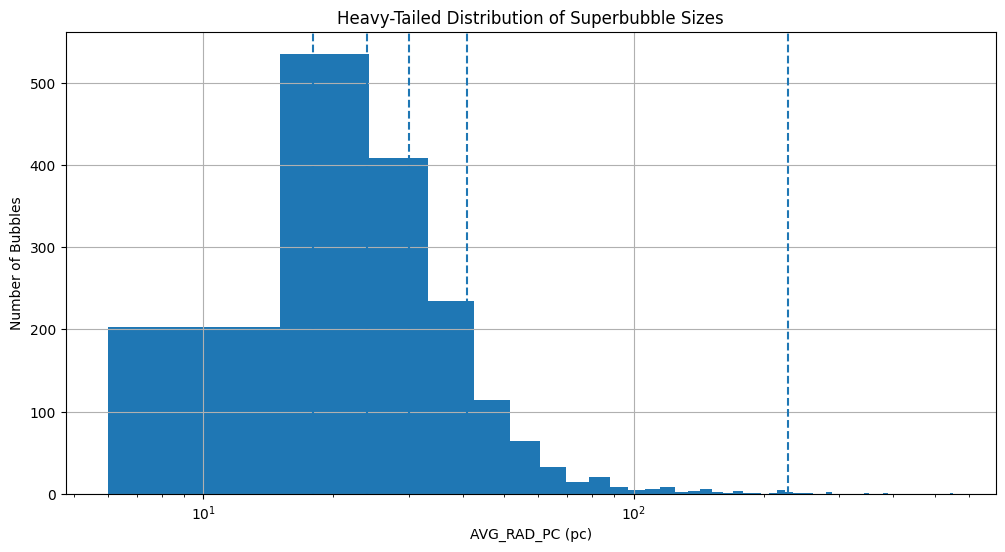

Saved: ../outputs/figures/distributions/avg_radius_distribution_categories_A.png


In [263]:
plt.figure(figsize=(12, 6))

plt.hist(df["AVG_RAD_PC"], bins=60)

boundaries = [
    18,
    24,
    30,
    41,
    edge_threshold
]

for b in boundaries:
    plt.axvline(
        b,
        linestyle="--"
    )

plt.xscale("log")

plt.xlabel("AVG_RAD_PC (pc)")
plt.ylabel("Number of Bubbles")

plt.title("Heavy-Tailed Distribution of Superbubble Sizes")

plt.grid(True)

if isDistributionplotting = True:
    boundary_path = os.path.join(
        output_file,
        "avg_radius_distribution_categories_A.png"
    )
    
    plt.savefig(boundary_path, dpi=300, bbox_inches="tight")
    
    plt.show()

    print("Saved:", boundary_path)

In [257]:
print(df["AVG_RAD_PC"].describe())

count    1694.000000
mean       34.394923
std        33.294749
min         6.000000
25%        19.000000
50%        26.000000
75%        37.000000
max       552.000000
Name: AVG_RAD_PC, dtype: float64


Saved annotated image to: ../data/processed/catalogue_all_bubbles_with_ids.png
